# P09 — Core Algorithms Tour  *(a starter kit of instincts, before the mind grows a brain)*

> **The story so far.** The mind can now draw a line, make a yes/no call, and — thanks to P08 — tell
> the difference between learning and memorising. It has *judgement*. But it still only knows one
> trick: fit a line, measure how wrong, step downhill. Before we hand it neurons in Part 2, it's
> worth meeting the other ways a mind can reason — the simple, sturdy instincts people invented long
> before neural nets. Think of this chapter as the mind's first toolbox: a drawer of reflexes it can
> reach for without a billion parameters.

Each of these classical algorithms is still the *right* tool for most everyday tabular problems —
the spreadsheet of customers, the table of sensor readings — and each one teaches an idea that
quietly returns in deep learning later. So we do a brisk tour: a one-paragraph instinct for each, a
tiny worked example by hand where it's illuminating, and a short scikit-learn run on a shared toy
dataset. We lean on sklearn's built-in datasets so the code stays short, but the *ideas* are what to
carry forward.

In [1]:
# shared toy datasets for the whole notebook
import numpy as np
from sklearn.datasets import load_iris, make_blobs
iris = load_iris()
Xi, yi = iris.data, iris.target              # 150 flowers, 4 features, 3 classes
print("iris   :", Xi.shape, "features, classes:", np.unique(yi))
Xb, yb = make_blobs(n_samples=150, centers=3, random_state=0, cluster_std=1.2)
print("blobs  :", Xb.shape, "for clustering")

iris   : (150, 4) features, classes: [0 1 2]
blobs  : (150, 2) for clustering


## B1 — k-Nearest Neighbours (kNN): "you are who your neighbours are"

Move to a new street and you'll guess what kind of neighbourhood it is by glancing at the houses
nearest yours — not by consulting a theory. That's the whole instinct here, and it's the laziest one
the mind has: don't build a model at all, just remember everything and, when asked about something
new, look at what's closest.

**Idea:** to classify a new point, find the `k` closest training points (by distance) and take a
majority vote. No training at all — it just memorises the data and looks up neighbours at predict
time ("lazy learning"). Distance is usually Euclidean: `√Σ(aᵢ−bᵢ)²` (the norm from P01).

**Worked example by hand.** New point `[1, 1]`; training points with labels:
```
A=[0,0] label 0   dist = √(1+1) = 1.41
B=[2,2] label 1   dist = √(1+1) = 1.41
C=[1,2] label 1   dist = √(0+1) = 1.00   <- nearest
```
With `k=1` → nearest is C → predict **label 1**.

In [2]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
Xi, yi = load_iris(return_X_y=True)

# by-hand 1-NN on the tiny example
pts = np.array([[0,0],[2,2],[1,2]]); labs=[0,1,1]; new=np.array([1,1])
d = np.linalg.norm(pts-new, axis=1)
print("distances:", np.round(d,2), "-> nearest is index", d.argmin(), "label", labs[d.argmin()])

Xtr,Xte,ytr,yte = train_test_split(Xi,yi,test_size=0.3,random_state=0)
for k in [1,5,15]:
    acc = KNeighborsClassifier(k).fit(Xtr,ytr).score(Xte,yte)
    print(f"k={k:>2}: iris test accuracy = {acc:.3f}")

distances: [1.41 1.41 1.  ] -> nearest is index 2 label 1
k= 1: iris test accuracy = 0.978
k= 5: iris test accuracy = 0.978
k=15: iris test accuracy = 0.978


## B2 — Decision Trees: a flowchart learned from data

A doctor narrowing a diagnosis doesn't weigh all symptoms at once — they ask one sharp question
("fever?"), then the next best question given that answer, branching down to a conclusion. A
decision tree is the mind learning to play that game of twenty questions on its own.

**Idea:** repeatedly split the data on the single question ("is feature 3 < 2.5?") that best
separates the classes, building a flowchart of yes/no questions. "Best" means the split that most
reduces impurity (Gini or entropy — yes, the entropy from P03). Trees are wonderfully
**interpretable**: you can read the rules. Their weakness: a deep tree memorises (overfits), which
motivates forests next.

In [3]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
Xi, yi = load_iris(return_X_y=True)
Xtr,Xte,ytr,yte = train_test_split(Xi,yi,test_size=0.3,random_state=0)

for depth in [1, 2, None]:
    t = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(Xtr,ytr)
    print(f"max_depth={str(depth):>4}: train={t.score(Xtr,ytr):.3f} test={t.score(Xte,yte):.3f}")
print("\nlearned rules (depth 2) — a readable flowchart:")
print(export_text(DecisionTreeClassifier(max_depth=2,random_state=0).fit(Xtr,ytr),
                  feature_names=load_iris().feature_names))

max_depth=   1: train=0.695 test=0.600
max_depth=   2: train=0.962 test=0.911
max_depth=None: train=1.000 test=0.978

learned rules (depth 2) — a readable flowchart:
|--- petal width (cm) <= 0.75
|   |--- class: 0
|--- petal width (cm) >  0.75
|   |--- petal length (cm) <= 4.95
|   |   |--- class: 1
|   |--- petal length (cm) >  4.95
|   |   |--- class: 2



Notice `max_depth=None` often gets **train=1.000** but lower test — a tree left to grow memorises.
That gap is overfitting (P05/P08), and the cure is an *ensemble*.

## B3 — Random Forests: a crowd of trees beats one expert

Ask one expert and you get one set of blind spots. Ask a hundred people who each saw a different
slice of the problem, then take the vote, and the individual mistakes tend to cancel — this is why
crowds guess the weight of an ox better than any single fairgoer. The mind can do the same with its
trees.

**Idea:** train many decision trees, each on a random subset of data and features, then average
their votes. Individual trees overfit in *different* ways, so their errors cancel — the crowd is
more accurate and more stable than any single tree. This "**ensemble**" idea (combine many weak
models) is one of the most reliable tricks in classical ML.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
Xi, yi = load_iris(return_X_y=True)
Xtr,Xte,ytr,yte = train_test_split(Xi,yi,test_size=0.3,random_state=0)

one = DecisionTreeClassifier(random_state=0).fit(Xtr,ytr).score(Xte,yte)
forest = RandomForestClassifier(n_estimators=100, random_state=0).fit(Xtr,ytr)
print("single deep tree test acc :", round(one,3))
print("random forest  test acc   :", round(forest.score(Xte,yte),3))
print("feature importances       :", dict(zip([f"f{i}" for i in range(4)],
                                               np.round(forest.feature_importances_,3))))
import numpy as np

single deep tree test acc : 0.978
random forest  test acc   : 0.978
feature importances       : {'f0': 0.102, 'f1': 0.024, 'f2': 0.48, 'f3': 0.394}


## B4 — Support Vector Machines (SVM): the widest street between classes

When you paint a line down a road to divide two lanes, you don't hug one curb — you aim for the
middle, leaving the most room on both sides. The mind's most elegant classical instinct does exactly
that: of all the ways to separate two groups, choose the boundary that leaves the widest empty street.

**Idea:** of all the lines that separate two classes, pick the one with the **largest margin** —
the widest gap to the nearest points of either class (those points are the "support vectors"). A
wide margin generalises better. With the **kernel trick**, SVMs can also draw *curved* boundaries
by implicitly mapping data to higher dimensions — a clever pre-deep-learning way to get
nonlinearity.

In [5]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
Xi, yi = load_iris(return_X_y=True)
Xtr,Xte,ytr,yte = train_test_split(Xi,yi,test_size=0.3,random_state=0)
for kernel in ["linear", "rbf"]:
    acc = SVC(kernel=kernel).fit(Xtr,ytr).score(Xte,yte)
    print(f"SVM kernel={kernel:>6}: test accuracy = {acc:.3f}  ({'straight' if kernel=='linear' else 'curved'} boundary)")

SVM kernel=linear: test accuracy = 0.978  (straight boundary)
SVM kernel=   rbf: test accuracy = 0.978  (curved boundary)


## B5 — Naive Bayes: Bayes' rule (P03) as a classifier

Your spam folder works on a hunch: an email full of "free", "winner", and "click now" *smells* like
junk. It doesn't reason about how those words relate — it just multiplies up the suspicious clues and
goes with the verdict. Crude, fast, and shockingly effective. That hunch is Bayes' rule from P03,
wearing a working hat.

**Idea:** apply Bayes' rule to pick the most probable class given the features, *naively* assuming
features are independent. Despite that crude assumption it works remarkably well for text (spam
filtering) and is extremely fast. This is P03's Bayes' rule put to work — `P(class | features) ∝
P(features | class)·P(class)`.

In [6]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
Xi, yi = load_iris(return_X_y=True)
Xtr,Xte,ytr,yte = train_test_split(Xi,yi,test_size=0.3,random_state=0)
nb = GaussianNB().fit(Xtr,ytr)
print("Naive Bayes test accuracy:", round(nb.score(Xte,yte),3))
print("class priors P(class)    :", dict(zip(range(3), nb.class_prior_.round(3))))

Naive Bayes test accuracy: 1.0
class priors P(class)    : {0: 0.324, 1: 0.305, 2: 0.371}


## B6 — k-Means: finding groups without labels (unsupervised)

Every instinct so far needed a teacher — someone to label each example *sick* or *healthy*, *spam* or
*real*. But pour a box of mixed coins onto a table and you'll sort them into piles without anyone
telling you the categories; the groups are just *there*, waiting to be found. This is the mind's first
taste of learning with **no labels at all** — discovering structure on its own.

**Idea:** partition data into `k` clusters by repeating two steps until stable:
1. **Assign** each point to the nearest cluster centre.
2. **Update** each centre to the mean of its assigned points.

No labels needed — it discovers structure. We run one full iteration *by hand* on 4 points so the
mechanism is concrete, then let sklearn finish.

**Worked example by hand.** Points `[0,0],[1,0],[10,0],[11,0]`, start centres `c0=[0,0], c1=[11,0]`:
```
assign: [0,0]->c0, [1,0]->c0, [10,0]->c1, [11,0]->c1
update: c0 = mean([0,0],[1,0]) = [0.5,0]   c1 = mean([10,0],[11,0]) = [10.5,0]
```
Centres have moved to the middle of each obvious group.

In [7]:
import numpy as np
from sklearn.datasets import make_blobs

# by-hand one iteration
P = np.array([[0,0],[1,0],[10,0],[11,0]], float); c0,c1 = P[0].copy(), P[3].copy()
assign = [0 if np.linalg.norm(p-c0)<np.linalg.norm(p-c1) else 1 for p in P]
c0n = P[[i for i,a in enumerate(assign) if a==0]].mean(0)
c1n = P[[i for i,a in enumerate(assign) if a==1]].mean(0)
print("assignments:", assign, " new centres:", c0n, c1n, " (hand [0.5,0] and [10.5,0])")

# the FULL algorithm from scratch (Lloyd's): just the two steps, repeated.
# (We hand-roll it instead of sklearn.KMeans both to keep every op visible and
#  to dodge a threadpoolctl/OpenBLAS bug in this locked environment.)
def kmeans(X, k, iters=20, seed=0):
    rng = np.random.default_rng(seed)
    centres = X[rng.choice(len(X), k, replace=False)]      # init: pick k random points
    for _ in range(iters):
        d = np.linalg.norm(X[:, None, :] - centres[None, :, :], axis=2)  # (n,k) distances
        labels = d.argmin(axis=1)                          # step 1: assign nearest centre
        centres = np.array([X[labels == j].mean(0) for j in range(k)])   # step 2: update
    return centres, labels

Xb, _ = make_blobs(n_samples=150, centers=3, random_state=0, cluster_std=1.2)
centres, labels = kmeans(Xb, k=3)
print("\nfrom-scratch k-means found 3 cluster centres:\n", np.round(centres, 2))
print("cluster sizes:", [int((labels==j).sum()) for j in range(3)])

assignments: [0, 0, 1, 1]  new centres: [0.5 0. ] [10.5  0. ]  (hand [0.5,0] and [10.5,0])

from-scratch k-means found 3 cluster centres:
 [[-1.85  2.97]
 [ 0.89  4.5 ]
 [ 2.14  0.98]]
cluster sizes: [49, 50, 51]


## B7 — PCA: compressing features by keeping the directions of most variance

Photograph a tall, thin building and you instinctively turn the camera sideways — you spend your
pixels on the direction where the interesting variation lives and ignore the flat, boring one. PCA is
the mind learning that same instinct: find the few directions where the data actually *spreads out*,
and describe everything using just those. It's the first whisper of an idea that will become central
later — that meaning can live in a small, well-chosen space.

**Idea:** find the directions along which the data varies most, and describe each point by its
coordinates along just the top few. This **reduces dimensions** (100 features → 2) while keeping
most of the information — great for visualisation and denoising. PCA is built from variance (P03)
and linear algebra (P01). The same "represent data in a smaller, meaningful space" instinct
reappears as **embeddings** in P18.

In [8]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
Xi, yi = load_iris(return_X_y=True)             # 4 features
p = PCA(n_components=2).fit(Xi)
X2 = p.transform(Xi)
print("original features :", Xi.shape[1], " -> reduced to:", X2.shape[1])
print("variance kept by the 2 components:", p.explained_variance_ratio_.round(3),
      " total:", round(p.explained_variance_ratio_.sum(),3))
print("-> 2 numbers retain ~", round(p.explained_variance_ratio_.sum()*100), "% of the 4-feature information")

original features : 4  -> reduced to: 2
variance kept by the 2 components: [0.925 0.053]  total: 0.978
-> 2 numbers retain ~ 98 % of the 4-feature information


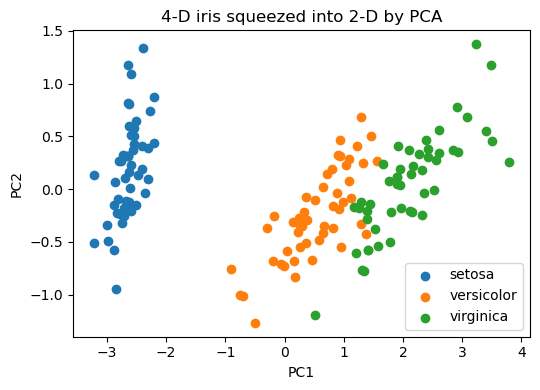

the three flower species separate cleanly even in just 2 dimensions.


In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
Xi, yi = load_iris(return_X_y=True)
X2 = PCA(n_components=2).fit_transform(Xi)
plt.figure(figsize=(5.5,4))
for c,name in zip([0,1,2], load_iris().target_names):
    m = yi==c; plt.scatter(X2[m,0], X2[m,1], label=name)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.title("4-D iris squeezed into 2-D by PCA")
plt.tight_layout(); plt.show()
print("the three flower species separate cleanly even in just 2 dimensions.")

## Recap — the classical toolbox

| Algorithm | Type | One-line idea | Echo in deep learning |
|-----------|------|---------------|-----------------------|
| kNN | supervised | vote of nearest neighbours | similarity search in RAG (P25) |
| Decision Tree | supervised | learned flowchart of splits | interpretability |
| Random Forest | supervised | average many trees (ensemble) | model ensembling |
| SVM | supervised | widest separating margin | margins / kernels |
| Naive Bayes | supervised | Bayes' rule + independence | probabilistic modelling |
| k-Means | unsupervised | iterate assign/update centres | clustering embeddings |
| PCA | unsupervised | keep top-variance directions | embeddings, compression |

## Common mistakes
1. **Not scaling features for distance methods** (kNN, SVM, k-means). A big-range feature dominates the distance — standardise first (P04).
2. **Letting a single tree grow unbounded.** It memorises; use depth limits or a forest.
3. **Picking `k` in kNN or k-means arbitrarily.** Use validation / the "elbow" method.
4. **Trusting PCA on unscaled data.** Variance is scale-dependent; standardise before PCA.
5. **Reaching for deep learning on small tabular data.** A random forest often wins there with far less effort.

## Exercises (do them in new code cells)
1. Scale iris with `StandardScaler` before kNN. Does accuracy change? Why might it?
2. Plot a decision tree's test accuracy vs `max_depth` from 1 to 10. Where does overfitting start?
3. Do one more by-hand k-means iteration from the B6 centres `[0.5,0]` and `[10.5,0]`. Do they move?
4. Run PCA with `n_components=3` on iris. How much variance do 3 components keep vs 2?
5. Which algorithm here would you try first on a 500-row spreadsheet with 10 columns, and why?

---

**Part 1 is complete, and so is the mind's childhood.** It can frame a problem, draw lines, make
calls, judge itself honestly, and reach for a whole drawer of instincts. But every tool here is a
single reflex — none of them can wire many small decisions into something that *thinks*. That is the
next great leap. Next we grow it a brain:
[P10 — Neurons & Neural Networks from scratch](P10_Neural_Networks.ipynb), where the single neuron
from P07 multiplies into layers and a new kind of mind begins to form.